In [ ]:
import nd2
from scipy.ndimage import zoom
import os
import glob
import napari
from ioMicro import *
import numpy as np
import tifffile
from scipy.spatial import cKDTree
from skimage import color
from skimage import img_as_ubyte  
import time
import pandas as pd
from tqdm import tqdm
import csv  
from skimage.measure import regionprops  

In [39]:
def expand_seg(im, npix=5, zinterp=2, xyinterp=4):
    A = im[::zinterp, ::xyinterp, ::xyinterp].copy()
    A_nonzero = A > 0
    from scipy import ndimage as nd
    A_dil = nd.binary_dilation(A_nonzero, nd.generate_binary_structure(3, 1), iterations=npix)
    X = np.array(np.where(A_dil.astype(np.float32) - A_nonzero)).T
    Xincell = np.array(np.where(A_nonzero)).T
    tree = cKDTree(Xincell)
    dists, ielems = tree.query(X)
    A[tuple(X.T)] = A[tuple(Xincell[ielems].T)]
    return A

def downsample_spots(spots, zinterp=2, xyinterp=4):
    # Adjust the coordinates of the spots according to the downsampling factors
    downsampled_spots = spots / np.array([zinterp, xyinterp, xyinterp])
    return downsampled_spots

def assign_spots_to_cells(spots, masks):
    print("Starting assign_spots_to_cells...")
    assigned_labels = np.zeros(spots.shape[0], dtype=int)  # Default to 0, indicating background
    
    # Convert spot coordinates from float to int by rounding down
    spots_idx = np.floor(spots).astype(int)

    # Debugging: Print shape of spots and masks
    print(f"Shape of spots: {spots.shape}")
    print(f"Shape of masks: {masks.shape}")

    # Ensure the spot indices are within the bounds of the mask array
    valid_idx = (spots_idx[:, 0] >= 0) & (spots_idx[:, 0] < masks.shape[0]) & \
                (spots_idx[:, 1] >= 0) & (spots_idx[:, 1] < masks.shape[1]) & \
                (spots_idx[:, 2] >= 0) & (spots_idx[:, 2] < masks.shape[2])

    # Debugging: Check how many spots are considered valid
    print(f"Number of valid spots: {np.sum(valid_idx)}")

    # Filter valid spots
    valid_spots_idx = spots_idx[valid_idx]

    # Assign each valid spot to its corresponding mask label
    for i, idx in enumerate(np.where(valid_idx)[0]):  # Iterate over indices of valid spots in the original array
        spot = valid_spots_idx[i]
        assigned_labels[idx] = masks[spot[0], spot[1], spot[2]]  # Assign label based on the mask value at the spot's location

    # Debugging: Print unique assigned labels to see if spots are being assigned correctly
    print(f"Unique assigned labels: {np.unique(assigned_labels)}")

    return spots[valid_idx], assigned_labels[valid_idx]

def calculate_mask_volumes(masks):
    unique_labels, counts = np.unique(masks, return_counts=True)
    return dict(zip(unique_labels, counts))

def calculate_centroids(masks):
    props = regionprops(masks)
    centroids = {prop.label: prop.centroid for prop in props}
    return centroids

In [ ]:
wd = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated'
raw_files_dir= wd + os.sep + 'rawdata'
result_dir = wd + os.sep + 'Result'
spot_dir = result_dir +  os.sep + 'called_spots'
drift_file_path = wd + os.sep + '\drift_correction\drift_correction_Point0002.npz'
thresholded_spots_dir = os.path.join(spot_dir, 'thresholded_spots')

masks_file_path = result_dir + os.sep + 'hyb001_Point0002_downsampled_masks_3d_cp_masks.tif'  # Update this path to your mask TIFF file
masks = tifffile.imread(masks_file_path)
masks_scale_back = zoom(masks, (2, 2, 2),order=0)
points = np.load(wd + os.sep + 'points.npz')['points']
# Load the drift correction parameters
drift_data = np.load(drift_file_path)['rtxyz']
# Downsample and dilate the mask image
dilated_masks = expand_seg(masks_scale_back)

In [ ]:
# Adjust these paths as needed
assigned_cells_output = os.path.join(spot_dir, 'spots_AssignedToCells_point0002_norm_vol_v2')
if not os.path.exists(assigned_cells_output):
    os.makedirs(assigned_cells_output)

n_hyb = 34
chs = [0, 1]
drift_file_path = os.path.join(wd, 'drift_correction', 'drift_correction_Point0002.npz')
drift_data = np.load(drift_file_path)['rtxyz']

file_path = os.path.join(result_dir, 'gene_hyb__th_index.csv')
parameters = {}

# Load parameters from the CSV file
with open(file_path, mode='r') as file:
    sample = file.read(1024)
    file.seek(0)
    dialect = csv.Sniffer().sniff(sample)
    reader = csv.reader(file, dialect)
    next(reader)
    for row in reader:
        if len(row) < 5:
            print(f"Skipping row with unexpected format: {row}")
            continue
        gene_name, nhyb, ch, b_th, cor_th = row
        parameters[(int(nhyb), int(ch))] = (gene_name, int(b_th), float(cor_th))

# Initialize data structure
start_time = time.time()
spot_counts_data = []
print("Initialized data structure.")
init_time = time.time() - start_time
print(f"Initialization took {init_time:.2f} seconds.")

# Calculate mask volumes and centroids
mask_volumes = calculate_mask_volumes(dilated_masks)
centroids = calculate_centroids(dilated_masks)

for nhyb in range(1, n_hyb + 1):
    for ch in chs:
        step_start_time = time.time()
        print(f'Processing nhyb {nhyb} ch {ch}...')

        try:
            if (nhyb, ch) in parameters:
                gene_name, b_th, cor_th = parameters[(nhyb, ch)]
            else:
                print(f"No threshold value found for hyb{nhyb} ch{ch}.")
                continue

            Xh_path = os.path.join(
                spot_dir,
                f"hyb{str(nhyb).zfill(3)}_Point0002_ch{ch}_th80.npz"
            )

            data = np.load(Xh_path)['arr_0']
            kp = (data[:, -3] > b_th) & (data[:, -4] > cor_th)
            filtered_data = data[kp]
            transformed_spots = apply_transformation(filtered_data[:, :3], drift_data[nhyb - 1])
            downsampled_spots = downsample_spots(transformed_spots)
            valid_spots, assigned_labels = assign_spots_to_cells(downsampled_spots, dilated_masks)

            for label in tqdm(np.unique(assigned_labels)):
                count = np.sum(assigned_labels == label)
                volume = mask_volumes.get(label, 0)
                centroid = centroids.get(label, (0, 0, 0))
                spot_counts_data.append({
                    'nhyb': nhyb, 
                    'ch': ch, 
                    'mask_id': label, 
                    'spot_count': count, 
                    'mask_volume': volume, 
                    'gene_name': gene_name,
                    'centroid_x': centroid[2],  # x coordinate
                    'centroid_y': centroid[1],  # y coordinate
                    'centroid_z': centroid[0]   # z coordinate
                })

        except Exception as e:
            print(f'Error processing nhyb {nhyb} ch {ch}: {e}')

        print(f'Completed nhyb {nhyb} ch {ch}. Total time: {time.time() - step_start_time:.2f} seconds.')

data_save_start_time = time.time()
df_spot_counts = pd.DataFrame(spot_counts_data)
csv_output_path = os.path.join(assigned_cells_output, 'spot_counts_per_mask_point0002.csv')
df_spot_counts.to_csv(csv_output_path, index=False)
print(f'Saved spot counts dataset to: {csv_output_path}')
print(f"Data saving took {time.time() - data_save_start_time:.2f} seconds.")

Initialized data structure.
Initialization took 0.07 seconds.
Processing nhyb 1 ch 0...
Starting assign_spots_to_cells...
Shape of spots: (101196, 3)
Shape of masks: (376, 576, 576)
Number of valid spots: 101088
Unique assigned labels: [    0     1     2 ... 31140 31142 31143]


100%|█████████████████████████████████████████████████████████████████████████| 11643/11643 [00:01<00:00, 11289.51it/s]


Completed nhyb 1 ch 0. Total time: 1.26 seconds.
Processing nhyb 1 ch 1...
Starting assign_spots_to_cells...
Shape of spots: (83550, 3)
Shape of masks: (376, 576, 576)
Number of valid spots: 83475
Unique assigned labels: [    0     8     9 ... 31140 31142 31143]


100%|███████████████████████████████████████████████████████████████████████████| 7802/7802 [00:00<00:00, 13758.03it/s]


Completed nhyb 1 ch 1. Total time: 0.80 seconds.
Processing nhyb 2 ch 0...
Starting assign_spots_to_cells...
Shape of spots: (51602, 3)
Shape of masks: (376, 576, 576)
Number of valid spots: 51517
Unique assigned labels: [    0     1     4 ... 31140 31142 31143]


...

Completed nhyb 33 ch 1. Total time: 0.23 seconds.
Processing nhyb 34 ch 0...
Starting assign_spots_to_cells...
Shape of spots: (7061, 3)
Shape of masks: (376, 576, 576)
Number of valid spots: 6988
Unique assigned labels: [    0    73   134 ... 31114 31118 31127]


100%|███████████████████████████████████████████████████████████████████████████| 1778/1778 [00:00<00:00, 50978.37it/s]


Completed nhyb 34 ch 0. Total time: 0.09 seconds.
Processing nhyb 34 ch 1...
Starting assign_spots_to_cells...
Shape of spots: (29408, 3)
Shape of masks: (376, 576, 576)
Number of valid spots: 29259
Unique assigned labels: [    0     2     5 ... 31127 31128 31143]


100%|███████████████████████████████████████████████████████████████████████████| 7388/7388 [00:00<00:00, 33711.62it/s]


Completed nhyb 34 ch 1. Total time: 0.33 seconds.
Saved spot counts dataset to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\spots_AssignedToCells_point0001_norm_vol_v2\spot_counts_per_mask_point0001.csv
Data saving took 14.64 seconds.


C:\Users\maysel0000\AppData\Local\Temp\ipykernel_21692\3009662603.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['normalized_spot_count'] = df_filtered['spot_count'] / df_filtered['mask_volume'] * median_volume


Original summary statistics:
count    652489.000000
mean       3609.811445
std        2721.727423
min           1.000000
25%        1710.000000
50%        3142.000000
75%        4898.000000
max       30768.000000
Name: mask_volume, dtype: float64

Filtered summary statistics:
count    554525.000000
mean       4174.259566
std        2565.420292
min         940.000000
25%        2496.000000
50%        3495.000000
75%        5281.000000
max       30768.000000
Name: mask_volume, dtype: float64

Volume threshold value: 939.00


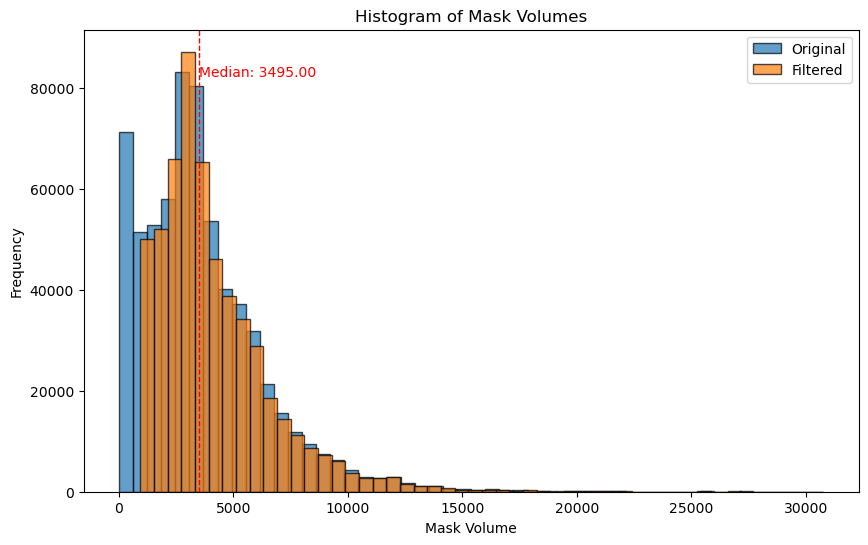

Normalized gene count matrix saved to: U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\spots_AssignedToCells_point0002_norm_vol_v2\normalized_gene_count_matrix_point0002.csv


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
assigned_cells_output = os.path.join(spot_dir, 'spots_AssignedToCells_point0002_norm_vol_v2')
csv_output_path = os.path.join(assigned_cells_output, 'spot_counts_per_mask_point0002.csv')

# Load the CSV file
# csv_file_path = r'U:\Scientific Data\RG-AS04-Data01\Oded_Mayseless\imaging_data\W1_images\20240418_seqFISH_multihyb_multianimal\consolidated\Result\called_spots\spots_AssignedToCells_point0002_norm_vol_v2\spot_counts_per_mask_point0002.csv'
df = pd.read_csv(csv_output_path)
# Load the CSV file
# df = df_spot_counts

# Exclude background mask_id = 0
df = df[df['mask_id'] != 0]

# Calculate the original summary statistics
original_summary = df['mask_volume'].describe()

# Calculate the 1% volume threshold
volume_threshold = np.percentile(df['mask_volume'], 15)

# Filter out masks with volumes below the 1% threshold
df_filtered = df[df['mask_volume'] > volume_threshold]

# Calculate the filtered summary statistics
filtered_summary = df_filtered['mask_volume'].describe()

# Calculate the median volume (excluding background)
median_volume = df_filtered['mask_volume'].median()

# Normalize the counts by mask volume and multiply by the median volume
df_filtered['normalized_spot_count'] = df_filtered['spot_count'] / df_filtered['mask_volume'] * median_volume

# Pivot the table to create a matrix with mask_id as index and genes as columns
gene_count_matrix = df_filtered.pivot_table(index='mask_id', columns='gene_name', values='normalized_spot_count', fill_value=0)

# Add centroid coordinates
centroids = df_filtered[['mask_id', 'centroid_x', 'centroid_y', 'centroid_z']].drop_duplicates().set_index('mask_id')
gene_count_matrix = gene_count_matrix.join(centroids)

# Save the normalized gene count matrix to a CSV file
normalized_matrix_csv_path = os.path.join(assigned_cells_output, 'normalized_gene_count_matrix_point0002.csv')
gene_count_matrix.to_csv(normalized_matrix_csv_path)

# Print original and filtered summary statistics
print("Original summary statistics:")
print(original_summary)
print("\nFiltered summary statistics:")
print(filtered_summary)
print(f"\nVolume threshold value: {volume_threshold:.2f}")

# Plot histogram of mask volumes
plt.figure(figsize=(10, 6))
plt.hist(df['mask_volume'], bins=50, edgecolor='k', alpha=0.7, label='Original')
plt.hist(df_filtered['mask_volume'], bins=50, edgecolor='k', alpha=0.7, label='Filtered')
plt.xlabel('Mask Volume')
plt.ylabel('Frequency')
plt.title('Histogram of Mask Volumes')
plt.axvline(median_volume, color='r', linestyle='dashed', linewidth=1)
plt.text(median_volume, plt.ylim()[1]*0.9, f'Median: {median_volume:.2f}', color='r')
plt.legend()
plt.show()

print(f'Normalized gene count matrix saved to: {normalized_matrix_csv_path}')
